In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

members = pd.read_csv("members.csv")
subscriptions = pd.read_csv("subscriptions.csv")
plans = pd.read_csv("membership_plans.csv")
branches = pd.read_csv("branches.csv")
workouts = pd.read_csv("workout_logs.csv")

In [2]:
print(members.shape)
print(subscriptions.shape)
print(workouts.shape)

(5000, 6)
(12000, 6)
(50000, 5)


In [3]:
df = subscriptions.merge(plans, on="plan_id") \
                  .merge(members, on="member_id") \
                  .merge(branches, on="branch_id")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   subscription_id  12000 non-null  int64 
 1   member_id        12000 non-null  int64 
 2   plan_id          12000 non-null  int64 
 3   start_date       12000 non-null  object
 4   end_date         12000 non-null  object
 5   status           12000 non-null  object
 6   plan_name        12000 non-null  object
 7   price            12000 non-null  int64 
 8   duration_months  12000 non-null  int64 
 9   member_name      12000 non-null  object
 10  age              12000 non-null  int64 
 11  gender           12000 non-null  object
 12  join_date        12000 non-null  object
 13  branch_id        12000 non-null  int64 
 14  branch_name      12000 non-null  object
 15  city             12000 non-null  object
dtypes: int64(7), object(9)
memory usage: 1.5+ MB


In [5]:
df.head()

,subscription_id,member_id,plan_id,start_date,end_date,status,plan_name,price,duration_months,member_name,age,gender,join_date,branch_id,branch_name,city
0,1,4477,4,2025-09-13,2026-09-13,Active,Elite,6000,12,Becky Howard,30,Female,2024-05-30,9,Marathahalli,Bangalore
1,2,4754,3,2024-09-03,2024-10-03,Expired,Premium,4000,6,Brandon Davis,19,Male,2024-07-14,13,Adyar,Chennai
2,3,1665,3,2025-12-27,2026-12-27,Active,Premium,4000,6,Tiffany Lloyd,49,Male,2023-06-30,3,HSR Layout,Bangalore
3,4,3694,2,2024-07-30,2025-07-30,Expired,Standard,2500,3,Richard Bullock,44,Male,2023-09-05,8,Jayanagar,Bangalore
4,5,913,2,2024-08-07,2025-08-07,Expired,Standard,2500,3,Michael Moyer,55,Female,2025-09-03,6,Whitefield,Bangalore


In [6]:
total_revenue = df["price"].sum()
total_revenue

41874000

In [7]:
revenue_by_plan = df.groupby("plan_name")["price"].agg(["count", "sum"]).sort_values("sum", ascending=False)
revenue_by_plan

,count,sum
plan_name,,
Elite,2908,17448000
Premium,3102,12408000
Standard,3033,7582500
Basic,2957,4435500


In [8]:
revenue_by_city = df.groupby("city")["price"].sum().sort_values(ascending=False)
revenue_by_city

city
Bangalore    27714000
Chennai       8630500
Hyderabad     2895500
Mumbai        2634000
Name: price, dtype: int64

In [9]:
df["start_date"] = pd.to_datetime(df["start_date"])
df["year_month"] = df["start_date"].dt.to_period("M")

monthly_revenue = df.groupby("year_month")["price"].sum()
monthly_revenue

year_month
2024-02     252000
2024-03    1720500
2024-04    1596500
2024-05    1719000
2024-06    1694500
2024-07    1856500
2024-08    1751000
2024-09    1585500
2024-10    1661000
2024-11    1850500
2024-12    1873500
2025-01    1883000
2025-02    1566000
2025-03    1990500
2025-04    1767500
2025-05    1671000
2025-06    1776000
2025-07    1774500
2025-08    1900500
2025-09    1713000
2025-10    1647000
2025-11    1695500
2025-12    1684000
2026-01    1787500
2026-02    1457500
Freq: M, Name: price, dtype: int64

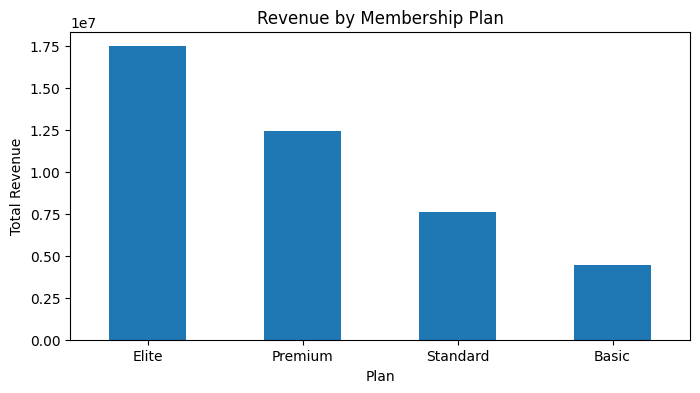

In [25]:
revenue_by_plan = df.groupby("plan_name")["price"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,4))
revenue_by_plan.plot(kind="bar")
plt.title("Revenue by Membership Plan")
plt.xlabel("Plan")
plt.ylabel("Total Revenue")
plt.xticks(rotation=0)
plt.show()

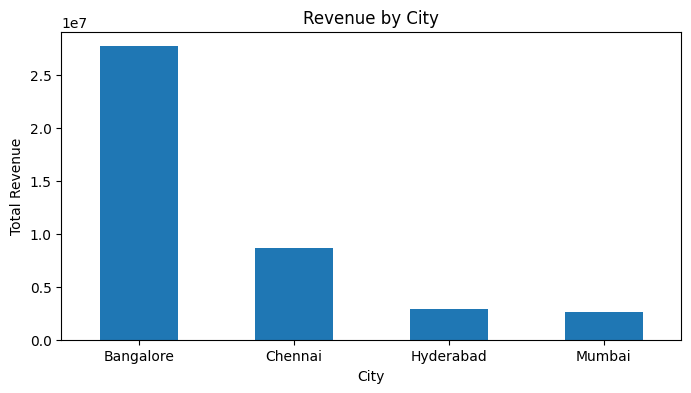

In [27]:
revenue_by_city = df.groupby("city")["price"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,4))
revenue_by_city.plot(kind="bar")
plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Total Revenue")
plt.xticks(rotation=0)
plt.show()

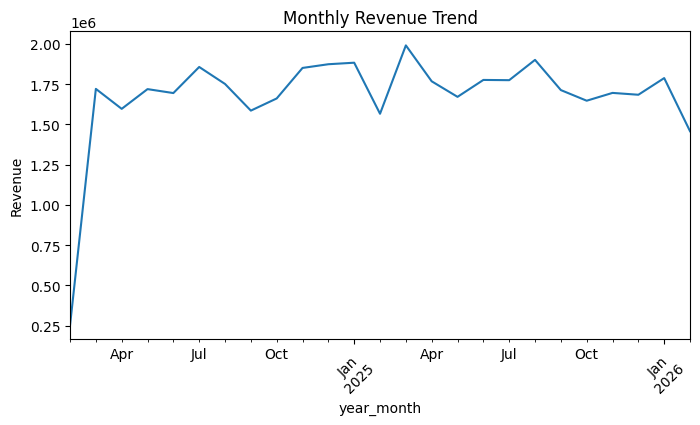

In [22]:
monthly_revenue.plot(kind="line", figsize=(8,4))
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

In [23]:
df["status"].value_counts(normalize=True) * 100

status
Expired    77.325
Active     22.675
Name: proportion, dtype: float64

In [14]:
churn_by_plan = df.groupby("plan_name")["status"].value_counts(normalize=True).unstack() * 100
churn_by_plan

status,Active,Expired
plan_name,,
Basic,23.334461,76.665539
Elite,23.074278,76.925722
Premium,22.372663,77.627337
Standard,21.958457,78.041543


In [17]:
workout_summary = workouts.groupby("member_id").agg(
    total_workouts=("log_id", "count"),
    avg_calories=("calories_burned", "mean")
).reset_index()

In [18]:
engagement_df = members.merge(workout_summary, on="member_id", how="left")
engagement_df.fillna(0, inplace=True)

In [19]:
engagement_df["total_workouts"].mean()

10.0

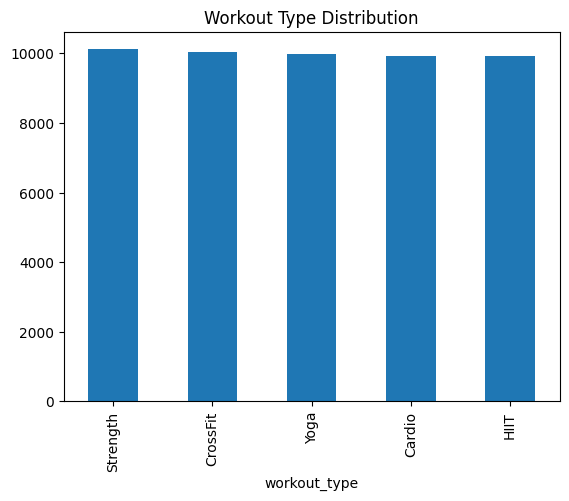

In [20]:
workouts["workout_type"].value_counts().plot(kind="bar")
plt.title("Workout Type Distribution")
plt.show()

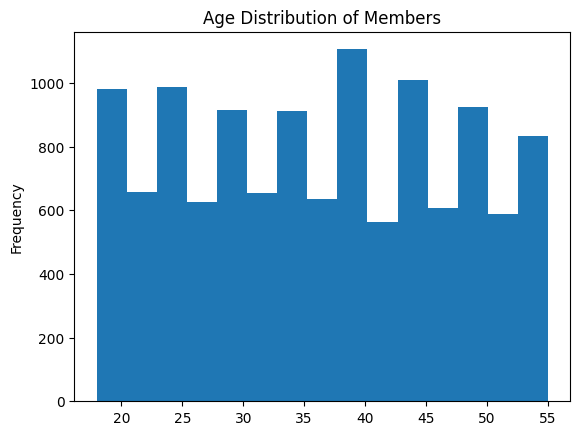

In [21]:
df["age"].plot(kind="hist", bins=15)
plt.title("Age Distribution of Members")
plt.show()

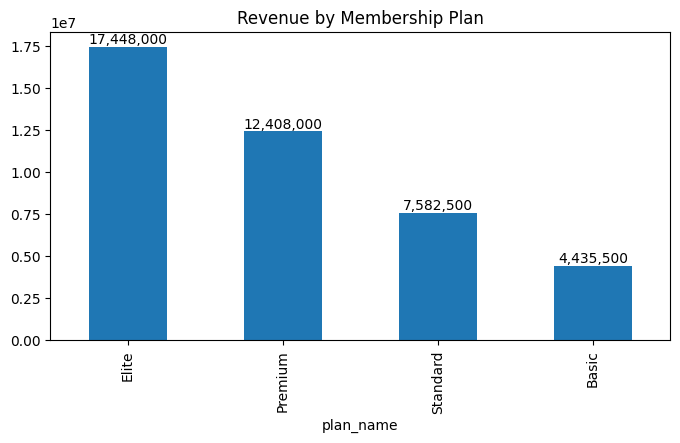

In [29]:
plt.figure(figsize=(8,4))
ax = revenue_by_plan.plot(kind="bar")

for i, v in enumerate(revenue_by_plan):
    ax.text(i, v, f"{v:,.0f}", ha='center', va='bottom')

plt.title("Revenue by Membership Plan")
plt.show()

In [30]:
engagement = workouts.groupby("member_id")["log_id"].count().reset_index()
engagement.columns = ["member_id", "total_workouts"]

engagement_df = df.merge(engagement, on="member_id", how="left")
engagement_df["total_workouts"].fillna(0, inplace=True)

engagement_df.groupby("status")["total_workouts"].mean()

C:\Users\tprat\AppData\Local\Temp\ipykernel_15208\2267522047.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  engagement_df["total_workouts"].fillna(0, inplace=True)


status
Active     10.095921
Expired    10.040845
Name: total_workouts, dtype: float64